# 1. Business understanding  

The goal of this project is to create a model that predicts whether a person has diabetes or prediabetes based on answers to a health questionnaire. The dataset contains information about health conditions, lifestyle, and demographic factors.

The objective is to compare Logistic Regression and Random Forest models and determine which approach performs best for this specific dataset. Different feature combinations and model configurations are also evaluated to determine whether a simpler model can achieve similar performance.

Because the model is intended for diabetes prediction, detecting positive diabetes cases is especially important. Therefore, the models are evaluated using accuracy, precision, recall, F1-score, and the number of false positive and false negative predictions. Particular attention is given to reducing false negatives, since failing to identify a person who may have diabetes can be more significant than incorrectly identifying a non-diabetic person as potentially diabetic.

The final goal is to select a model that provides the best balance between predictive performance and model complexity.

# 2. Data understanding

The dataset contains health, lifestyle, and demographic information that can be used to study diabetes. The target variable indicates whether an individual has diabetes or prediabetes.

In [1]:
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

In [2]:
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 

# data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets
  
# variable information 
print(cdc_diabetes_health_indicators.variables) 


                    name     role     type      demographic  \
0                     ID       ID  Integer              NaN   
1        Diabetes_binary   Target   Binary              NaN   
2                 HighBP  Feature   Binary              NaN   
3               HighChol  Feature   Binary              NaN   
4              CholCheck  Feature   Binary              NaN   
5                    BMI  Feature  Integer              NaN   
6                 Smoker  Feature   Binary              NaN   
7                 Stroke  Feature   Binary              NaN   
8   HeartDiseaseorAttack  Feature   Binary              NaN   
9           PhysActivity  Feature   Binary              NaN   
10                Fruits  Feature   Binary              NaN   
11               Veggies  Feature   Binary              NaN   
12     HvyAlcoholConsump  Feature   Binary              NaN   
13         AnyHealthcare  Feature   Binary              NaN   
14           NoDocbcCost  Feature   Binary             

In [3]:
X.dtypes

HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [4]:
y.dtypes

Diabetes_binary    int64
dtype: object

In [5]:
X.head(10)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1,1,40,1,0,0,0,0,1,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,25,1,0,0,1,0,0,...,0,1,3,0,0,0,0,7,6,1
2,1,1,1,28,0,0,0,0,1,0,...,1,1,5,30,30,1,0,9,4,8
3,1,0,1,27,0,0,0,1,1,1,...,1,0,2,0,0,0,0,11,3,6
4,1,1,1,24,0,0,0,1,1,1,...,1,0,2,3,0,0,0,11,5,4
5,1,1,1,25,1,0,0,1,1,1,...,1,0,2,0,2,0,1,10,6,8
6,1,0,1,30,1,0,0,0,0,0,...,1,0,3,0,14,0,0,9,6,7
7,1,1,1,25,1,0,0,1,0,1,...,1,0,3,0,0,1,0,11,4,4
8,1,1,1,30,1,0,1,0,1,1,...,1,0,5,30,30,1,0,9,5,1
9,0,0,1,24,0,0,0,0,0,1,...,1,0,2,0,0,0,1,8,4,3


In [6]:
import matplotlib.pyplot as plt

def plot_data(X):
    plt.figure(figsize=(20, 15))

    for i, col in enumerate(X.select_dtypes(include=['int', 'float'])):
        plt.subplot(5, 5, i + 1)
        X[col].plot(kind='hist', title=col)
        plt.xlabel(col)

    plt.tight_layout()
    plt.show()

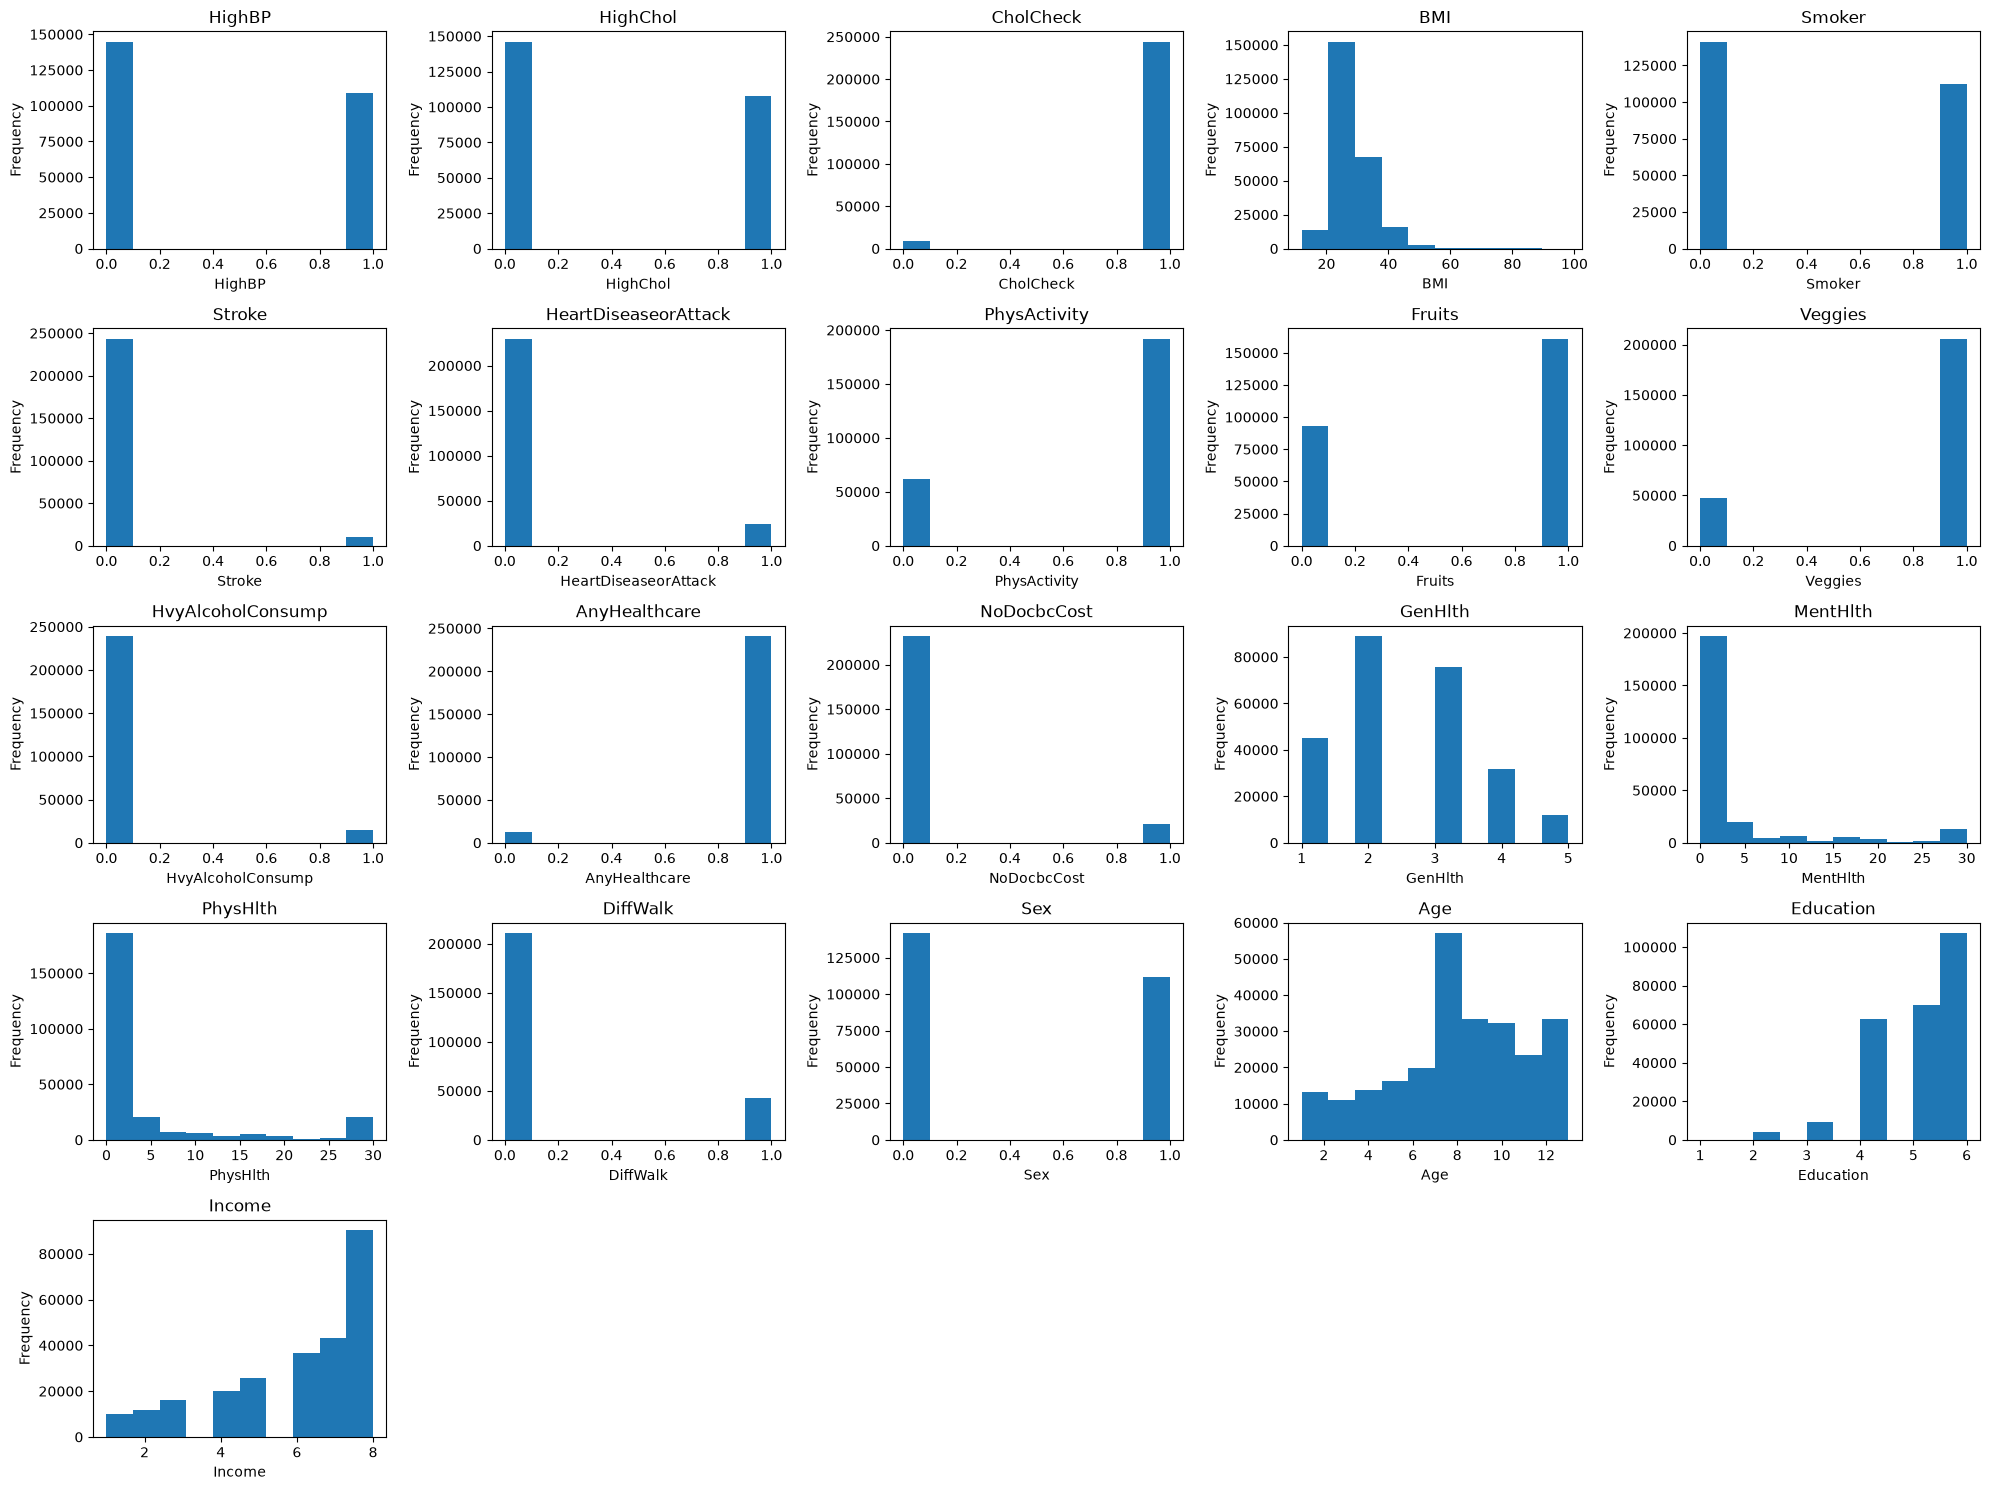

In [7]:
plot_data(X)

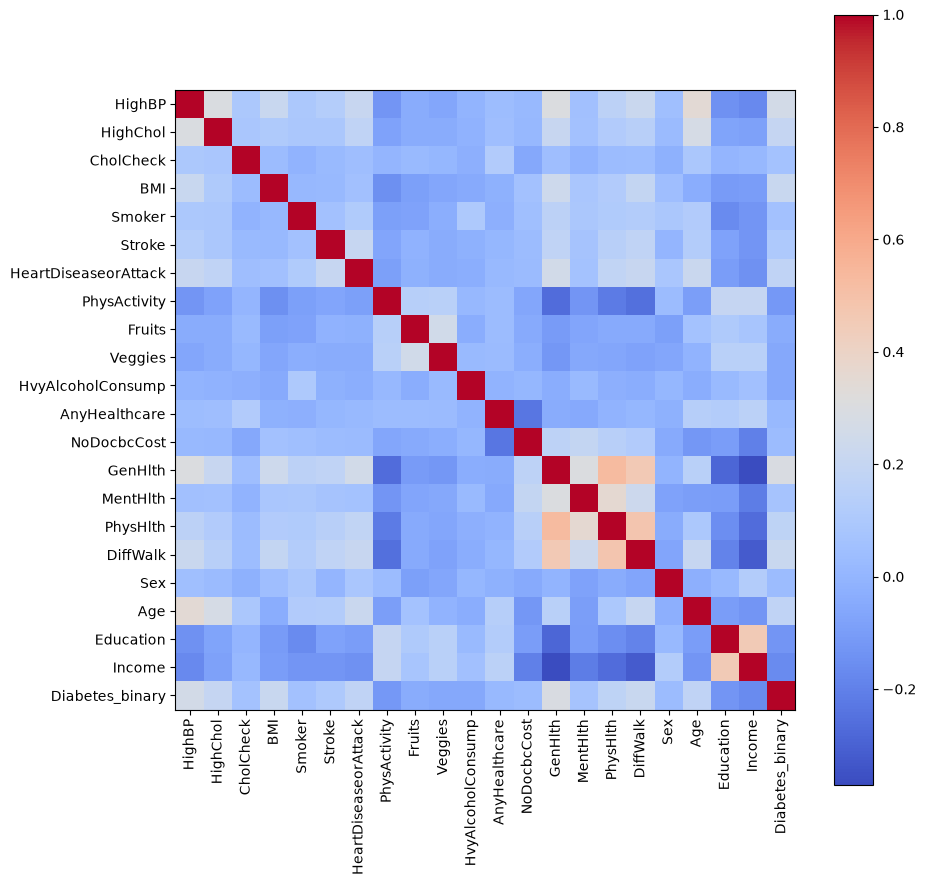

In [8]:
#correlation matrix
df = pd.concat([X, y], axis=1)

corr = df.corr()

plt.figure(figsize=(10, 10))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.show()

## Conclusion

There is multiple colums. All of them are based on query and most of them are binary *`Yes`* / *`No`* based or sex such as *`Diabetes_binary`*, *`HighBP`*, *`HighChol`*, *`CholCheck`*, *`Smoker`*, *`Stroke`*, *`HeartDiseaseorAttack`*, *`PhysActivity`*, *`Fruits`*, *`Veggies`*, *`HvyAlcoholConsump`*, *`AnyHealthcare`*, *`NoDocbcCost`*, *`DiffWalk`* and *`Sex`*. Multiple options were on *`BMI`*, *`GenHlth`*, *`MentHlth`*, *`PhysHlth`*, *`Age`*, *`Education`* and *`Income`*.

Heatmap indicates some correlation between *`Diabetes_binary`* and *`HighBP`*, *`HighChol`*, *`BMI`*, *`HeartDiseaseorAttack`*, *`GenHlth`*, *`PhysHlth`*, *`DiffWalk`* and *`Age`*. The strongest positive correlations appear to be with *`GenHlth`*, *`HighBP`* and *`BMI`*. There are also weaker negative correlations with variables such as *`PhysActivity`*, *`Education`* and *`Income`*.

# 3. Data preparation

First lets make sure there are no empty values.

In [9]:
X.isna().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [10]:
y.isna().sum()

Diabetes_binary    0
dtype: int64

No empty values in data set and no outliers because data is based on questionnaire.

## Logical regression

The data was split into training and testing sets. The features were also standardized to ensure that they are on a comparable scale. This is useful for logistic regression and makes the model coefficients easier to compare. Shape of y needs to be changed from 2D column vector to 1D vector.

### All-model

In [11]:
y_logistic = y.squeeze()

X_logistic = X

X_train, X_test, y_train, y_test = train_test_split(
    X_logistic,
    y_logistic,
    test_size=0.2,
    random_state=123,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Top5-model

In [12]:
top5_features = [
    "GenHlth",
    "HighBP",
    "BMI",
    "HighChol",
    "Age"
]

X_top5 = X[top5_features]

X_train_top5, X_test_top5, y_train_top5, y_test_top5 = train_test_split(
    X_top5,
    y_logistic,
    test_size=0.2,
    random_state=123,
    stratify=y_logistic
)

scaler_top5 = StandardScaler()

X_train_top5 = scaler_top5.fit_transform(X_train_top5)
X_test_top5 = scaler_top5.transform(X_test_top5)

### Top8-model

In [13]:
top8_features = [
    "GenHlth",
    "HighBP",
    "BMI",
    "HighChol",
    "Age",
    "Income",
    "DiffWalk",
    "HeartDiseaseorAttack"
]

X_top8 = X[top8_features]

X_train_top8, X_test_top8, y_train_top8, y_test_top8 = train_test_split(
    X_top8,
    y_logistic,
    test_size=0.2,
    random_state=123,
    stratify=y_logistic
)

scaler_top8 = StandardScaler()

X_train_top8 = scaler_top8.fit_transform(X_train_top8)
X_test_top8 = scaler_top8.transform(X_test_top8)

### Random Forest - data split

Random Forest does not require feature scaling, so the original features are used directly. The same 80/20 split and random state are used so the results are comparable with the logistic models.

In [14]:
y_forest = y.squeeze()

X_train_forest, X_test_forest, y_train_forest, y_test_forest = train_test_split(
    X,
    y_forest,
    test_size=0.2,
    random_state=123,
    stratify=y_forest
)

# 4. Modeling

A logistic regression model was trained using the training data to predict if an individual has diabetes or prediabetes.

## Logistic

A logistic regression model was trained using the training data to predict if an individual has diabetes or prediabetes.

### All- model

In [15]:
logistic_model_all = LogisticRegression(max_iter=1000)

logistic_model_all.fit(X_train, y_train)

y_pred = logistic_model_all.predict(X_test)

### top5_ model

In [16]:
logistic_model_top5 = LogisticRegression(max_iter=1000)

logistic_model_top5.fit(X_train_top5, y_train_top5)

y_prob_top5 = logistic_model_top5.predict_proba(X_test_top5)[:, 1]
y_pred_top5_035 = (y_prob_top5 >= 0.35).astype(int)

### Top8- model

In [17]:
logistic_model_top8 = LogisticRegression(max_iter=1000)

logistic_model_top8.fit(X_train_top8, y_train_top8)

y_prob_top8 = logistic_model_top8.predict_proba(X_test_top8)[:, 1]
y_pred_top8_035 = (y_prob_top8 >= 0.35).astype(int)

## Random Forest

A Random Forest model was trained with 100 trees, bootstrap sampling, `max_depth=15`, `max_samples=0.75`, and `max_features=0.30`. Random Forest was chosen as a comparison to logistic regression because it can capture non-linear relationships between features and does not require feature scaling. The same training and testing split was used so the results are directly comparable.

In [18]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=100,
    bootstrap=True,
    max_depth=15,
    max_samples=0.75,
    max_features=0.30,
    random_state=20
)

forest_model.fit(X_train_forest, y_train_forest)

y_pred_forest = forest_model.predict(X_test_forest)

# 5. Evaluation

Evaluation is made by comparing the performance of the trained models using several classification metrics: accuracy, precision, recall, F1-score, and the numbers of false positive and false negative predictions.

Special attention is given to recall and false negatives because the model is used for diabetes prediction. Missing a person who may have diabetes can be more significant than incorrectly classifying a non-diabetic person as potentially diabetic.

The models are also compared using different classification thresholds to evaluate how the balance between false positives and false negatives changes. The final model is selected based on overall predictive performance and the ability to detect positive diabetes cases.

## Logistic regression model

### All variables model

### Permutation importance evaluatiom

,Feature,Importance
13,GenHlth,0.0886
0,HighBP,0.0575
3,BMI,0.0557
1,HighChol,0.0388
18,Age,0.0229
20,Income,0.0211
16,DiffWalk,0.0148
6,HeartDiseaseorAttack,0.0141
2,CholCheck,0.0051
10,HvyAlcoholConsump,0.0043


/var/folders/wv/6d453psx4ks3q_hd1g1sn8zm0000gn/T/ipykernel_8065/1845493223.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


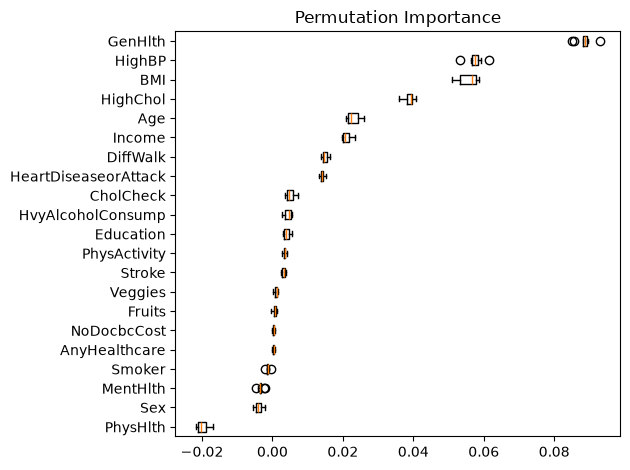

In [19]:
importance = permutation_importance(
    logistic_model_all,
    X_test,
    y_test,
    n_repeats=10,
    random_state=123,
    scoring="recall"
)

sorted_idx = importance.importances_mean.argsort()

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance.importances_mean
}).sort_values("Importance", ascending=False)

display(importance_df.round(4))

fig, ax = plt.subplots()

ax.boxplot(
    importance.importances[sorted_idx].T,
    vert=False,
    tick_labels=X.columns[sorted_idx]
)

ax.set_title("Permutation Importance")
fig.tight_layout()
plt.show()

### Permutation importance conclusion

Permutation importance indicates that *`GenHlth`* (value: *`0.0886`*), *`HighBP`* (value: *`0.0575`*), *`BMI`* (value: *`0.0557`*), *`HighChol`* (value: *`0.0388`*), *`Age`* (value: *`0.0229`*), *`Income`* (value: *`0.0211`*), *`DiffWalk`* (value: *`0.0148`*) and *`HeartDiseaseorAttack`* (value: *`0.0141`*) show the greatest importance compared to the rest.

## Evaluating logistic models

Evaluating models by accuracy, precision, recall, F1-score, and the numbers of false positive and false negative predictions, and comparing them with each other.

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import pandas as pd


def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    }


results = []
results_logistic = []

# Default threshold 0.5
results.append(
    evaluate_model(
        logistic_model_all,
        X_test,
        y_test,
        "All features",
        0.5
    )
)

results_logistic.append(
    evaluate_model(
        logistic_model_all,
        X_test,
        y_test,
        "All features",
        0.5
    )
)

results.append(
    evaluate_model(
        logistic_model_top8,
        X_test_top8,
        y_test_top8,
        "Top 8",
        0.5
    )
)

results_logistic.append(
    evaluate_model(
        logistic_model_top8,
        X_test_top8,
        y_test_top8,
        "Top 8",
        0.5
    )
)

results.append(
    evaluate_model(
        logistic_model_top5,
        X_test_top5,
        y_test_top5,
        "Top 5",
        0.5
    )
)

results_logistic.append(
    evaluate_model(
        logistic_model_top5,
        X_test_top5,
        y_test_top5,
        "Top 5",
        0.5
    )
)



# Threshold 0.35
results.append(
    evaluate_model(
        logistic_model_all,
        X_test,
        y_test,
        "All features",
        0.35
    )
)

results_logistic.append(
    evaluate_model(
        logistic_model_all,
        X_test,
        y_test,
        "All features",
        0.35
    )
)

results.append(
    evaluate_model(
        logistic_model_top8,
        X_test_top8,
        y_test_top8,
        "Top 8",
        0.35
    )
)

results_logistic.append(
    evaluate_model(
        logistic_model_top8,
        X_test_top8,
        y_test_top8,
        "Top 8",
        0.35
    )
)

results.append(
    evaluate_model(
        logistic_model_top5,
        X_test_top5,
        y_test_top5,
        "Top 5",
        0.35
    )
)

results_logistic.append(
    evaluate_model(
        logistic_model_top5,
        X_test_top5,
        y_test_top5,
        "Top 5",
        0.35
    )
)


comparison_df_logistic = pd.DataFrame(results_logistic)

display(comparison_df_logistic.round(4))

,Model,Threshold,Accuracy,Precision,Recall,F1-score,FP,FN,TP,TN
0,All features,0.50,0.8629,0.5285,0.1509,0.2348,952,6002,1067,42715
1,Top 8,0.50,0.8629,0.5288,0.1456,0.2283,917,6040,1029,42750
2,Top 5,0.50,0.8625,0.5254,0.1359,0.2160,868,6108,961,42799
3,All features,0.35,0.8514,0.4564,0.3497,0.3960,2944,4597,2472,40723
4,Top 8,0.35,0.8521,0.4581,0.3375,0.3887,2823,4683,2386,40844
5,Top 5,0.35,0.8521,0.4578,0.3320,0.3849,2780,4722,2347,40887


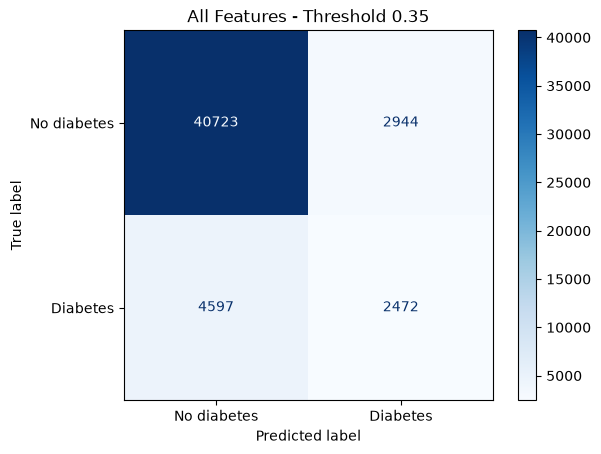

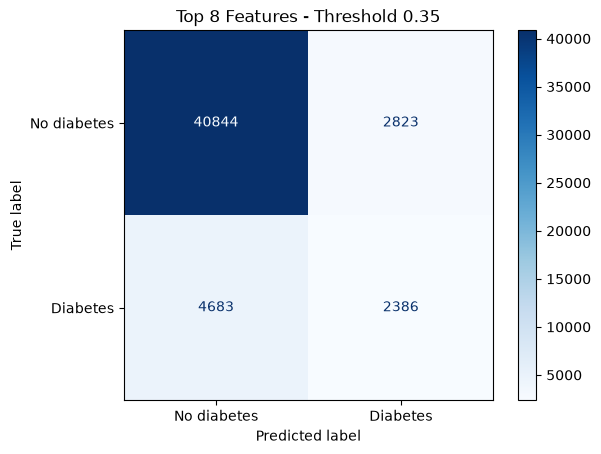

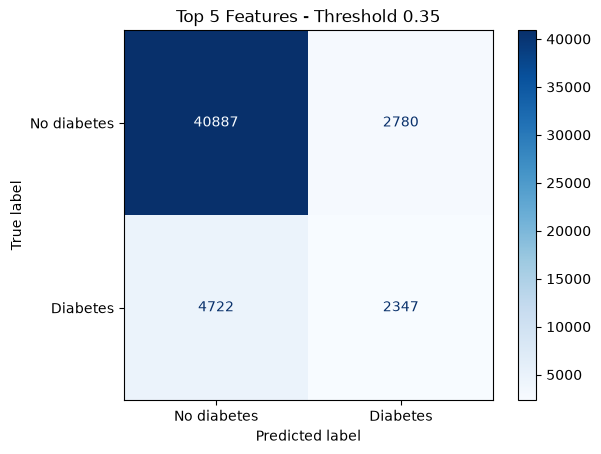

In [21]:
threshold = 0.35


# All features
y_prob_all = logistic_model_all.predict_proba(X_test)[:, 1]
y_pred_all_035 = (y_prob_all >= threshold).astype(int)

cm_all = confusion_matrix(y_test, y_pred_all_035)

ConfusionMatrixDisplay(
    confusion_matrix=cm_all,
    display_labels=["No diabetes", "Diabetes"]
).plot(cmap="Blues")

plt.title("All Features - Threshold 0.35")
plt.show()


# Top 8
y_prob_top8 = logistic_model_top8.predict_proba(X_test_top8)[:, 1]
y_pred_top8_035 = (y_prob_top8 >= threshold).astype(int)

cm_top8 = confusion_matrix(y_test_top8, y_pred_top8_035)

ConfusionMatrixDisplay(
    confusion_matrix=cm_top8,
    display_labels=["No diabetes", "Diabetes"]
).plot(cmap="Blues")

plt.title("Top 8 Features - Threshold 0.35")
plt.show()


# Top 5
y_prob_top5 = logistic_model_top5.predict_proba(X_test_top5)[:, 1]
y_pred_top5_035 = (y_prob_top5 >= threshold).astype(int)

cm_top5 = confusion_matrix(y_test_top5, y_pred_top5_035)

ConfusionMatrixDisplay(
    confusion_matrix=cm_top5,
    display_labels=["No diabetes", "Diabetes"]
).plot(cmap="Blues")

plt.title("Top 5 Features - Threshold 0.35")
plt.show()

## Random Forest model

The Random Forest model is evaluated with cross-validation, accuracy, precision, recall, F1-score, and a confusion matrix, following the same metrics used for the logistic regression models.

Random Forest model:
CV accuracy: 0.8662
Accuracy: 0.8661
Precision: 0.5782
Recall: 0.1439
F1-score: 0.2304

              precision    recall  f1-score   support

 No diabetes       0.88      0.98      0.93     43667
    Diabetes       0.58      0.14      0.23      7069

    accuracy                           0.87     50736
   macro avg       0.73      0.56      0.58     50736
weighted avg       0.83      0.87      0.83     50736



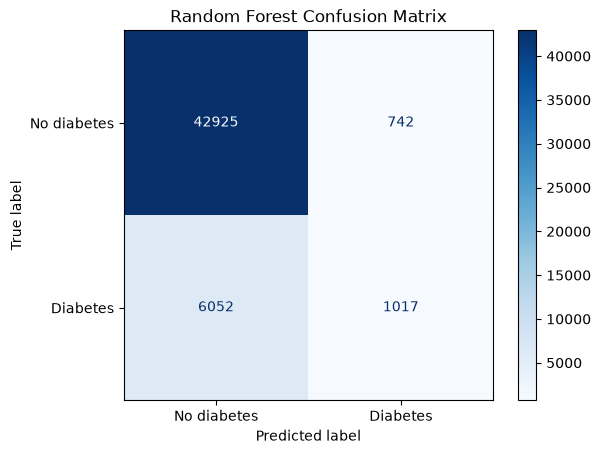

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

cv_scores_forest = cross_val_score(
    forest_model,
    X_train_forest,
    y_train_forest,
    cv=10,
    scoring="accuracy"
)

print("Random Forest model:")
print(f"CV accuracy: {cv_scores_forest.mean():.4f}")
print(f"Accuracy: {accuracy_score(y_test_forest, y_pred_forest):.4f}")
print(f"Precision: {precision_score(y_test_forest, y_pred_forest):.4f}")
print(f"Recall: {recall_score(y_test_forest, y_pred_forest):.4f}")
print(f"F1-score: {f1_score(y_test_forest, y_pred_forest):.4f}")

print("")
print(
    classification_report(
        y_test_forest,
        y_pred_forest,
        target_names=["No diabetes", "Diabetes"]
    )
)

cm_forest = confusion_matrix(y_test_forest, y_pred_forest)

ConfusionMatrixDisplay(
    confusion_matrix=cm_forest,
    display_labels=["No diabetes", "Diabetes"]
).plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.show()

In [23]:
results_random = []

results.append(
    evaluate_model(
        forest_model,
        X_test_forest,
        y_test_forest,
        "Random Forest",
        0.5
    )
)

results_random.append(
    evaluate_model(
        forest_model,
        X_test_forest,
        y_test_forest,
        "Random Forest",
        0.5
    )
)

results.append(
    evaluate_model(
        forest_model,
        X_test_forest,
        y_test_forest,
        "Random Forest",
        0.35
    )
)

results_random.append(
    evaluate_model(
        forest_model,
        X_test_forest,
        y_test_forest,
        "Random Forest",
        0.35
    )
)

comparison_df_forest = pd.DataFrame(results_random)

display(comparison_df_forest.round(4))

,Model,Threshold,Accuracy,Precision,Recall,F1-score,FP,FN,TP,TN
0,Random Forest,0.50,0.8661,0.5782,0.1439,0.2304,742,6052,1017,42925
1,Random Forest,0.35,0.8502,0.4557,0.3863,0.4182,3262,4338,2731,40405


Random Forest, threshold 0.35:
Accuracy: 0.8502
Precision: 0.4557
Recall: 0.3863
F1-score: 0.4182


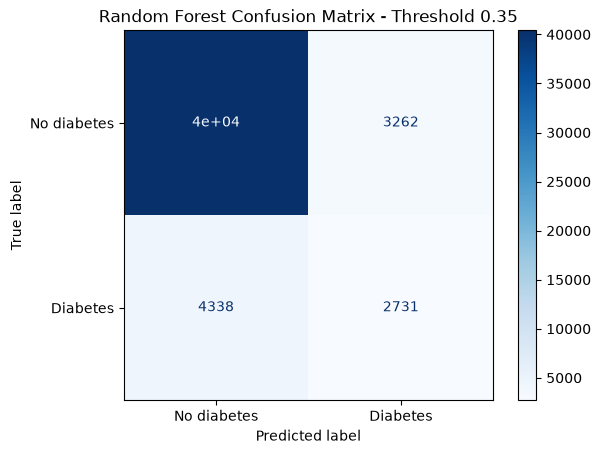

In [24]:
y_prob_forest = forest_model.predict_proba(X_test_forest)[:, 1]
y_pred_forest_035 = (y_prob_forest >= 0.35).astype(int)

print("Random Forest, threshold 0.35:")
print(f"Accuracy: {accuracy_score(y_test_forest, y_pred_forest_035):.4f}")
print(f"Precision: {precision_score(y_test_forest, y_pred_forest_035):.4f}")
print(f"Recall: {recall_score(y_test_forest, y_pred_forest_035):.4f}")
print(f"F1-score: {f1_score(y_test_forest, y_pred_forest_035):.4f}")

cm_forest_035 = confusion_matrix(y_test_forest, y_pred_forest_035)

ConfusionMatrixDisplay(
    confusion_matrix=cm_forest_035,
    display_labels=["No diabetes", "Diabetes"]
).plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix - Threshold 0.35")
plt.show()

## Conclusions

### Logistic conclusion

The default threshold produces *`952`* false positives and *`6002`* false negatives. This means that relatively few non-diabetic individuals are incorrectly classified as diabetic, but a large number of diabetic individuals are missed by the model.

When the threshold is lowered to *`0.35`*, false negatives decrease from *`6002`* to *`4597`*, while false positives increase from *`952`* to *`2944`*. Therefore, lowering the threshold improves the model's ability to detect diabetes, but at the cost of incorrectly classifying more non-diabetic individuals as diabetic.

In this case, the number of false negatives decreases by *`1405`*, while false positives increase by *`1992`*. For diabetes prediction, reducing false negatives can be more important because missing a person who may have diabetes is generally more serious than incorrectly identifying someone as potentially diabetic.

When comparing the three logistic regression models with a threshold of *`0.35`*, the differences between the models are relatively small. The all-features model achieves an accuracy of *`0.8514`*, precision of *`0.4564`*, recall of *`0.3497`*, and F1-score of *`0.3960`*. The Top 8 model achieves a slightly higher accuracy of *`0.8521`* and precision of *`0.4581`*, but its recall decreases to *`0.3375`* and its F1-score to *`0.3887`*. The Top 5 model also reaches an accuracy of *`0.8521`* with precision of *`0.4578`*, while recall decreases further to *`0.3320`* and the F1-score to *`0.3849`*.

The all-features model therefore performs best overall when the ability to detect diabetic individuals is emphasized. It has the highest recall and F1-score of the three models, meaning that it identifies more positive cases while maintaining the best overall balance between precision and recall.

However, the differences between the models are small. The Top 8 and Top 5 models achieve almost identical accuracy and precision compared with the all-features model, while using fewer input variables. Therefore, although the all-features model is selected as the best-performing model, its advantage over the Top 8 and Top 5 models is relatively minor.

## Random forest conclusions

In [25]:
comparison_df = pd.DataFrame(results)

display(comparison_df.round(4))

,Model,Threshold,Accuracy,Precision,Recall,F1-score,FP,FN,TP,TN
0,All features,0.50,0.8629,0.5285,0.1509,0.2348,952,6002,1067,42715
1,Top 8,0.50,0.8629,0.5288,0.1456,0.2283,917,6040,1029,42750
2,Top 5,0.50,0.8625,0.5254,0.1359,0.2160,868,6108,961,42799
3,All features,0.35,0.8514,0.4564,0.3497,0.3960,2944,4597,2472,40723
4,Top 8,0.35,0.8521,0.4581,0.3375,0.3887,2823,4683,2386,40844
5,Top 5,0.35,0.8521,0.4578,0.3320,0.3849,2780,4722,2347,40887
6,Random Forest,0.50,0.8661,0.5782,0.1439,0.2304,742,6052,1017,42925
7,Random Forest,0.35,0.8502,0.4557,0.3863,0.4182,3262,4338,2731,40405


Random Forest performed better than logistic regression with best performance with threshhold `0.35`. At there it had the highest F1 score at 42% and recall at 39%. At threshhold `0.50` precision and accuracy were better compared to `0.35` but recall much worse. In addition `0.35` had lowest false negatives which we want to minimize.

## **Tänne vertailu ja yhdistelmälopputulokset**

näyttäs et random forest hieman paremmin arvioi 0.35 thersholdilla TP mut FP kustannuksilla mut kannattaa kattoo viel paremmin silmin